# Neural sequences in short-term memory — Orhan & Ma (2019) and Zhou et al. (2023)

This notebook reproduces core findings from two studies of **neural sequences** in short-term / working memory:

> Orhan, A. E. & Ma, W. J. (2019). A diverse range of factors affect the nature of neural representations underlying short-term memory. *Nature Neuroscience*, 22, 275–283.

> Zhou, S., Seay, M., Taxidis, J., Golshani, P. & Buonomano, D. V. (2023). Multiplexing working memory and time in the trajectories of neural networks. *Nature Human Behaviour*, 7, 1056–1070.

Both use task-trained recurrent networks as in-silico models and ask when delay-period activity becomes **sequential** rather than **persistent**.

**What is reproduced here**

*Part I — Orhan & Ma (2019):*
1. **Task temporal complexity** — COMP shows higher Sequentiality Index (SI) than 2AFC.
2. **Strong recurrent coupling** `sigma_0` — increases oscillatory modes and SI in 2AFC.
3. **Strong L2 regularization** `rho` — decreases SI in COMP.
4. **Variable delay duration** — decreases SI relative to fixed-delay 2AFC.
5. **Non-normal, asymmetric recurrent connectivity** — recurrent weights sorted by peak response time show forward asymmetry.

*Part II — Zhou et al. (2023):*
6. **Ramp-to-sequence transition during T+WM training** (Figure 3) — the network transitions from low-dimensional persistent/ramping activity early in training to high-dimensional, cue-specific neural sequences as the temporal-expectation output is learned.

**Modeling choice.** We follow both papers and use deterministic **rate units** (ReLU RNN), not spiking neurons. The Orhan section uses a vanilla discrete-time rate RNN (`ctrnn` with `dt=None`), and the Zhou section uses a Dale-constrained leaky ReLU RNN (`ei_rnn`).

**Quick-run note:** The cells below set modest step counts so the notebook can be validated quickly. Increase `MAX_STEPS` for the full reproduction.

In [108]:
import os, sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from neuralrnn import AutoConfig, AutoModel, Trainer, TrainingArguments
from neuralrnn import SupervisedObjective
from neuralrnn.data.cognitive_task_dataset import CognitiveTaskDataset
from neuralrnn.analysis import (
    compute_sequentiality_index,
    sort_neurons_by_peak_time,
    weight_profile_by_peak_order,
)

SEED = 42
MODEL_DIR = './models/15'
os.makedirs(MODEL_DIR, exist_ok=True)

# Set to a small number for quick validation; increase for actual reproduction.
MAX_STEPS = 4000
BATCH_SIZE = 128
LR = 4e-5
HIDDEN_DIM = 100   # paper uses 500 recurrent units

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
torch.manual_seed(SEED)
np.random.seed(SEED)

print('torch:', torch.__version__)
print('device:', device)
print('MAX_STEPS:', MAX_STEPS)

torch: 2.4.1+cu121
device: cpu
MAX_STEPS: 4000


---

## Part I — Orhan & Ma (2019)

In this part we train vanilla ReLU rate RNNs on short-term memory tasks and measure how task structure shapes sequential versus persistent delay activity.

### 1. Task definitions

We need three tasks from Orhan & Ma (2019). All use the same input encoding: 25 Poisson input neurons with Gaussian tuning curves on a linear feature axis. Time step `dt = 10 ms`.

- **2AFC** (low temporal complexity): a single stimulus `s ∈ {−15, +15}` is shown for 250 ms, followed by a 1000 ms delay and a 250 ms response period. The target (`−1` or `+1`) is constant during the response and does not depend on any post-delay probe.
- **COMP** (high temporal complexity): two stimuli `s1, s2 ∈ [−40, 40]` are shown sequentially (250 ms each) separated by a 1000 ms delay; the network must report whether `s2 > s1` during the final 250 ms response. The correct response depends on the second stimulus, so the network must keep track of temporal context.
- **Variable 2AFC**: same as 2AFC, but the delay duration is drawn uniformly from `{100, 400, 700, 1000}` ms on each trial. The response always occurs at the same fixed absolute time, so the network cannot use elapsed time as a cue.

`STIM_RATE` and `SPON_RATE` are **per-time-bin mean firing rates** (not total counts over the epoch). Targets are masked everywhere except the response period, so the loss only trains readout at the end of the trial.

In [109]:
DELTA_T = 10.0
N_IN = 25
STIM_DURATION = 250
DELAY_DURATION = 1000
RESP_DURATION = 250
STIM_RATE = 1.0
SPON_RATE = 0.1
SIGMA_TC = 15

stim_discrete = int(STIM_DURATION / DELTA_T)
delay_discrete = int(DELAY_DURATION / DELTA_T)
resp_discrete = int(RESP_DURATION / DELTA_T)


def _tuning_curve_centers(n_in=N_IN, span=40.0):
    return np.linspace(-span, span, n_in)


def _gaussian_tuning(s, phi, sigma_tc=SIGMA_TC):
    tau = 1.0 / sigma_tc ** 2
    return np.exp(-0.5 * tau * (s - phi) ** 2)


def generate_orhan_2afc(num_trials=1000, n_in=N_IN, seed=None, poisson=True):
    """Orhan 2019 2AFC."""
    if seed is not None:
        np.random.seed(seed)
    phi = _tuning_curve_centers(n_in)
    total = stim_discrete + delay_discrete + resp_discrete
    inputs = torch.zeros((num_trials, total, n_in), dtype=torch.float32)
    targets = torch.zeros((num_trials, total, 1), dtype=torch.float32)
    mask = torch.zeros((num_trials, total, 1), dtype=torch.float32)
    conditions = []
    for i in range(num_trials):
        choice = np.random.choice([0.0, 1.0])
        s = -15.0 if choice == 0.0 else 15.0
        target_val = 1.0 if choice == 1.0 else -1.0

        # NOTE: STIM_RATE / SPON_RATE are per-time-bin mean firing rates,
        # NOT total counts over the epoch. Removing the old division by epoch
        # length gives the network a strong enough signal to learn.
        stim_mean = STIM_RATE * _gaussian_tuning(s, phi)
        delay_mean = SPON_RATE * np.ones(n_in)
        resp_mean = SPON_RATE * np.ones(n_in)

        inputs[i, :stim_discrete] = torch.from_numpy(stim_mean).float()
        inputs[i, stim_discrete:stim_discrete + delay_discrete] = torch.from_numpy(delay_mean).float()
        inputs[i, stim_discrete + delay_discrete:] = torch.from_numpy(resp_mean).float()
        if poisson:
            inputs[i] = torch.poisson(inputs[i])

        targets[i, stim_discrete + delay_discrete:, 0] = target_val
        mask[i, stim_discrete + delay_discrete:, 0] = 1.0
        conditions.append({'choice': int(choice), 'stimulus': s, 'target': target_val})
    return inputs, targets, mask, conditions


def generate_orhan_comparison(num_trials=1000, n_in=N_IN, seed=None, poisson=True):
    """Orhan 2019 comparison (COMP)."""
    if seed is not None:
        np.random.seed(seed)
    phi = _tuning_curve_centers(n_in, span=50.0)
    total = stim_discrete + delay_discrete + stim_discrete + resp_discrete
    inputs = torch.zeros((num_trials, total, n_in), dtype=torch.float32)
    targets = torch.zeros((num_trials, total, 1), dtype=torch.float32)
    mask = torch.zeros((num_trials, total, 1), dtype=torch.float32)
    conditions = []
    for i in range(num_trials):
        s1 = 80.0 * np.random.rand() - 40.0
        s2 = 80.0 * np.random.rand() - 40.0
        choice = 1.0 if s2 > s1 else 0.0
        target_val = 1.0 if choice == 1.0 else -1.0

        stim1_mean = STIM_RATE * _gaussian_tuning(s1, phi)
        stim2_mean = STIM_RATE * _gaussian_tuning(s2, phi)
        delay_mean = SPON_RATE * np.ones(n_in)
        resp_mean = SPON_RATE * np.ones(n_in)

        inputs[i, :stim_discrete] = torch.from_numpy(stim1_mean).float()
        inputs[i, stim_discrete:stim_discrete + delay_discrete] = torch.from_numpy(delay_mean).float()
        inputs[i, stim_discrete + delay_discrete:stim_discrete + delay_discrete + stim_discrete] = torch.from_numpy(stim2_mean).float()
        inputs[i, stim_discrete + delay_discrete + stim_discrete:] = torch.from_numpy(resp_mean).float()
        if poisson:
            inputs[i] = torch.poisson(inputs[i])

        targets[i, stim_discrete + delay_discrete + stim_discrete:, 0] = target_val
        mask[i, stim_discrete + delay_discrete + stim_discrete:, 0] = 1.0
        conditions.append({'s1': s1, 's2': s2, 'choice': int(choice), 'target': target_val})
    return inputs, targets, mask, conditions


def generate_orhan_var2afc(num_trials=1000, n_in=N_IN, seed=None, poisson=True):
    """Orhan 2019 variable-delay 2AFC."""
    if seed is not None:
        np.random.seed(seed)
    phi = _tuning_curve_centers(n_in)
    delay_options = [100, 400, 700, 1000]
    max_total = stim_discrete + delay_discrete + resp_discrete
    inputs = torch.zeros((num_trials, max_total, n_in), dtype=torch.float32)
    targets = torch.zeros((num_trials, max_total, 1), dtype=torch.float32)
    mask = torch.zeros((num_trials, max_total, 1), dtype=torch.float32)
    conditions = []
    for i in range(num_trials):
        choice = np.random.choice([0.0, 1.0])
        s = -15.0 if choice == 0.0 else 15.0
        target_val = 1.0 if choice == 1.0 else -1.0
        delay_ms = np.random.choice(delay_options)
        this_delay = int(delay_ms / DELTA_T)

        stim_mean = STIM_RATE * _gaussian_tuning(s, phi)
        delay_mean = SPON_RATE * np.ones(n_in)
        resp_mean = SPON_RATE * np.ones(n_in)

        inputs[i, :stim_discrete] = torch.from_numpy(stim_mean).float()
        inputs[i, stim_discrete:stim_discrete + this_delay] = torch.from_numpy(delay_mean).float()
        inputs[i, stim_discrete + delay_discrete:stim_discrete + delay_discrete + resp_discrete] = torch.from_numpy(resp_mean).float()
        if poisson:
            inputs[i] = torch.poisson(inputs[i])

        targets[i, stim_discrete + delay_discrete:stim_discrete + delay_discrete + resp_discrete, 0] = target_val
        mask[i, stim_discrete + delay_discrete:stim_discrete + delay_discrete + resp_discrete, 0] = 1.0
        conditions.append({'choice': int(choice), 'stimulus': s, 'target': target_val, 'delay_ms': delay_ms})
    return inputs, targets, mask, conditions

### Visualize example trials

The plots below show the Poisson input raster and the masked target for one example trial of each task.

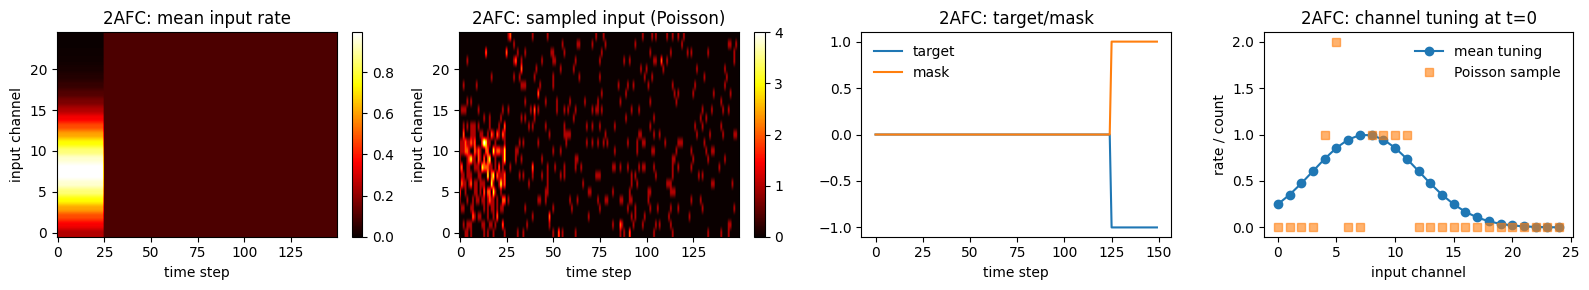

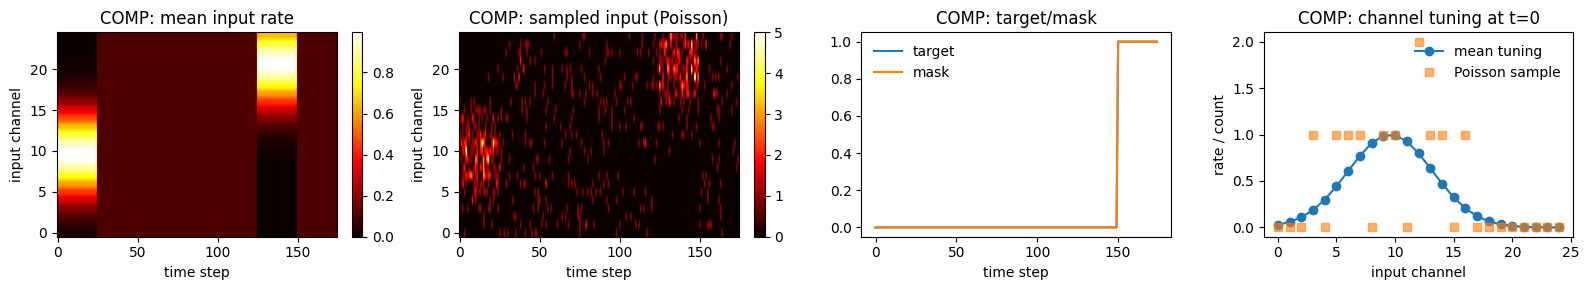

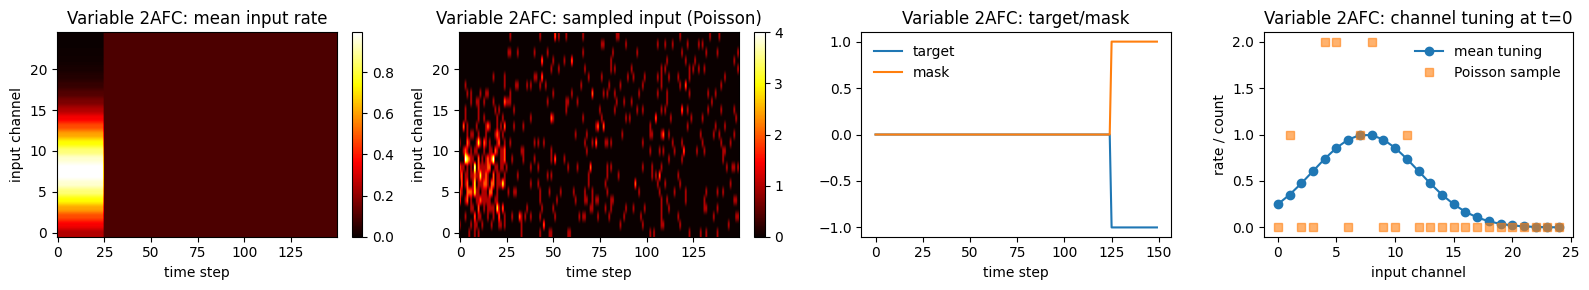

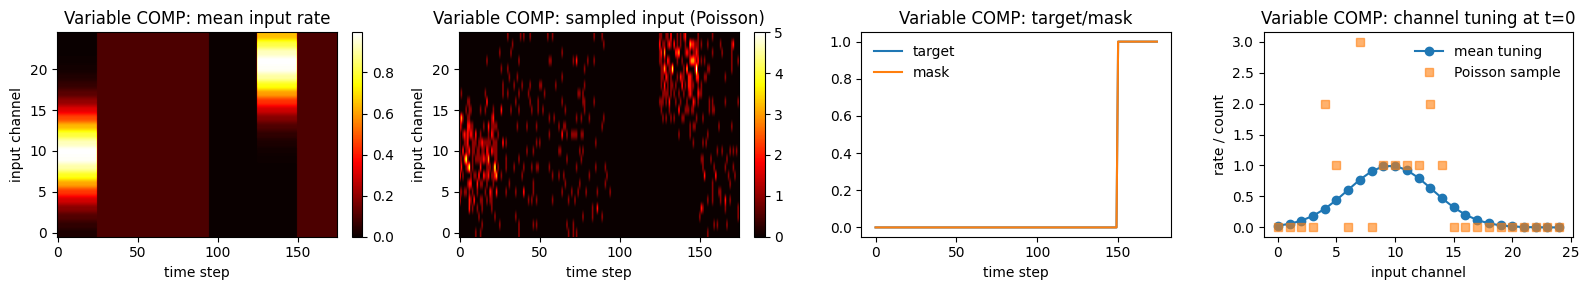

In [110]:
def plot_task_examples(name, inputs, targets, mask, mean_inputs=None, stim_t=0):
    """Visualize one example trial: mean rate, sampled Poisson counts, target/mask, and tuning curve."""
    n_plots = 4 if mean_inputs is not None else 3
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 3))
    if mean_inputs is not None:
        ax_mean, ax_sample, ax_trace, ax_tuning = axes
    else:
        ax_sample, ax_trace, ax_tuning = axes
        ax_mean = None

    if mean_inputs is not None:
        im = ax_mean.imshow(mean_inputs[0].T, aspect='auto', cmap='hot', origin='lower', vmin=0)
        ax_mean.set_title(f'{name}: mean input rate')
        ax_mean.set_xlabel('time step')
        ax_mean.set_ylabel('input channel')
        plt.colorbar(im, ax=ax_mean, fraction=0.046)

    im = ax_sample.imshow(inputs[0].T, aspect='auto', cmap='hot', origin='lower', vmin=0)
    ax_sample.set_title(f'{name}: sampled input (Poisson)')
    ax_sample.set_xlabel('time step')
    ax_sample.set_ylabel('input channel')
    plt.colorbar(im, ax=ax_sample, fraction=0.046)

    ax_trace.plot(targets[0, :, 0], label='target')
    ax_trace.plot(mask[0, :, 0], label='mask')
    ax_trace.set_title(f'{name}: target/mask')
    ax_trace.set_xlabel('time step')
    ax_trace.legend(frameon=False)

    # Tuning curve at the first stimulus time step
    if mean_inputs is not None:
        ax_tuning.plot(mean_inputs[0, stim_t], 'o-', color='C0', label='mean tuning')
        ax_tuning.plot(inputs[0, stim_t], 's', alpha=0.6, color='C1', label='Poisson sample')
    else:
        ax_tuning.plot(inputs[0, stim_t], 's', alpha=0.6, color='C1', label='Poisson sample')
    ax_tuning.set_title(f'{name}: channel tuning at t={stim_t}')
    ax_tuning.set_xlabel('input channel')
    ax_tuning.set_ylabel('rate / count')
    ax_tuning.legend(frameon=False)

    plt.tight_layout()
    plt.show()


# Generate both mean (no Poisson) and sampled inputs for visualization
inputs_2afc, targets_2afc, mask_2afc, conds_2afc = generate_orhan_2afc(num_trials=3, seed=SEED, poisson=True)
inputs_2afc_mean, _, _, _ = generate_orhan_2afc(num_trials=3, seed=SEED, poisson=False)

inputs_comp, targets_comp, mask_comp, conds_comp = generate_orhan_comparison(num_trials=3, seed=SEED, poisson=True)
inputs_comp_mean, _, _, _ = generate_orhan_comparison(num_trials=3, seed=SEED, poisson=False)

inputs_var, targets_var, mask_var, conds_var = generate_orhan_var2afc(num_trials=3, seed=SEED, poisson=True)
inputs_var_mean, _, _, _ = generate_orhan_var2afc(num_trials=3, seed=SEED, poisson=False)

    num_trials=3, seed=SEED, poisson=True)

plot_task_examples('2AFC', inputs_2afc, targets_2afc, mask_2afc, inputs_2afc_mean, stim_t=0)
plot_task_examples('COMP', inputs_comp, targets_comp, mask_comp, inputs_comp_mean, stim_t=0)
plot_task_examples('Variable 2AFC', inputs_var, targets_var, mask_var, inputs_var_mean, stim_t=0)

### 2. Network architecture, initialization, and objective

We use NeuralRNN's `ctrnn` model with `dt=None`, which sets `alpha = 1.0` and gives the discrete-time vanilla RNN used in the paper:

$$r_t = \mathrm{ReLU}(W_r r_{t-1} + W_x x_t + b).$$

The recurrent weights are initialized according to the paper's parametrization:

$$W_r(0) = \lambda_0 I + \sigma_0 \Sigma_{\mathrm{off}},$$

where `lambda_0` controls the intrinsic time constant / persistence and `sigma_0` controls the strength of inter-neuron coupling. Larger `sigma_0` seeds stronger oscillatory modes in the initial connectivity.

The objective is masked mean-squared error on the response-period readout, handled by `SupervisedObjective(task_type='regression')` together with the task mask.

### Load-or-train helper

Each model is saved under `./models/15/`. If a checkpoint exists we load it; otherwise we train and save. This makes the notebook re-runnable without retraining everything.

In [112]:
def evaluate_accuracy(model, ds, n_trials=300):
    """Fraction of trials where the sign of the averaged response-period output matches the target."""
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        test = ds.get_all_trials()
        inputs = test['inputs'][:n_trials].to(device)
        targets = test['targets'][:n_trials].to(device)
        mask = test['mask'][:n_trials].to(device)
        out = model(inputs)
        m = mask.float()
        # Average predictions / targets over the masked response period
        pred = (out.outputs * m).sum(dim=1) / m.sum(dim=1).clamp_min(1.0)
        true = (targets * m).sum(dim=1) / m.sum(dim=1).clamp_min(1.0)
        acc = ((pred * true) > 0).float().mean().item()
    return acc

def load_or_train(name, task_name, lambda_0=0.9, sigma_0=0.05, weight_decay=1e-5,
                    steps=MAX_STEPS, hidden=HIDDEN_DIM):
    save_path = os.path.join(MODEL_DIR, name)
    if os.path.exists(os.path.join(save_path, 'config.json')):
        print(f'Loading {name} from {save_path}')
        model = AutoModel.from_pretrained(save_path)
    else:
        ds = make_dataset(task_name, num_trials=200, batch_size=BATCH_SIZE)
        cfg = AutoConfig.for_model('ctrnn',
                                   input_dim=ds.input_dim,
                                   latent_dim=hidden,
                                   output_dim=ds.output_dim,
                                   dt=None,
                                   activation='relu',
                                   trainable_h0=False)
        model = AutoModel.from_config(cfg)
        init_orhan_recurrent(model, lambda_0=lambda_0, sigma_0=sigma_0)

        objective = SupervisedObjective(task_type='regression')
        args = TrainingArguments(
            max_steps=steps,
            batch_size=BATCH_SIZE,
            learning_rate=LR,
            weight_decay=weight_decay,
            grad_clip_norm=1.0,
            log_every=200, #max(steps // 8, 1),
            device=device,
            seed=SEED,
        )
        Trainer(model, ds, objective, args).train()
        model.save_pretrained(save_path)
        print(f'Saved {name} to {save_path}')

    # Evaluate test accuracy on a fresh test set
    ds_test = make_dataset(task_name, num_trials=300, batch_size=300)
    acc = evaluate_accuracy(model, ds_test)
    print(f'[{name}] test accuracy: {acc:.3f}')
    return model, acc

### 3. Experiment 1 — Task temporal complexity: COMP > 2AFC

We train two networks with identical hyperparameters on 2AFC and COMP. Because COMP requires the network to compare two sequentially presented stimuli, it has higher temporal complexity and is expected to produce more sequential delay-period activity.

In [113]:
model_2afc, acc_2afc = load_or_train('orhan_2afc', '2afc', lambda_0=0.9, sigma_0=0.05)
model_comp, acc_comp = load_or_train('orhan_comp', 'comp', lambda_0=0.9, sigma_0=0.05)

Loading orhan_2afc from ./models/15\orhan_2afc
[orhan_2afc] test accuracy: 1.000
Loading orhan_comp from ./models/15\orhan_comp
[orhan_comp] test accuracy: 0.903


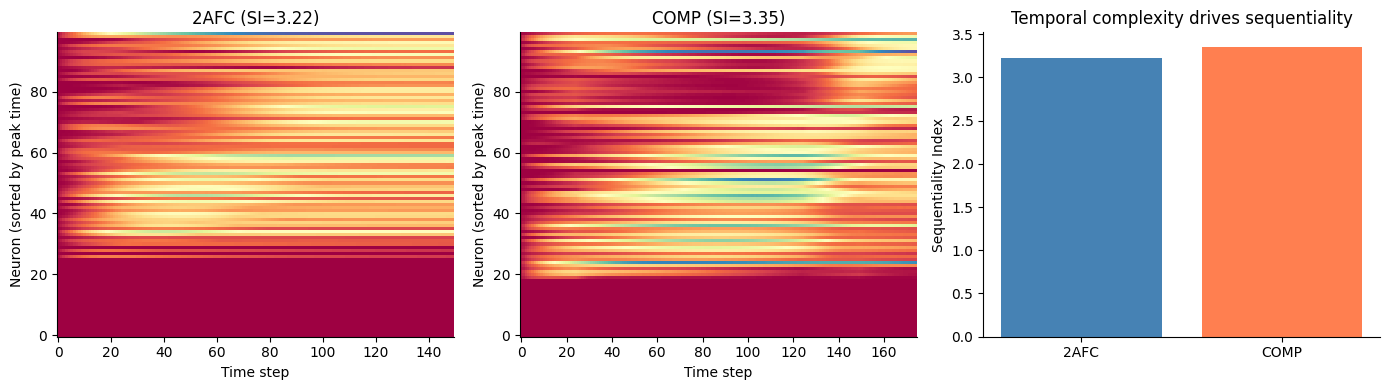

In [114]:
def collect_states(model, ds, n_trials=300):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        test = ds.get_all_trials()
        inputs = test['inputs'][:n_trials].to(device)
        out = model(inputs)
    return out.states.cpu().numpy()


def evaluate_accuracy(model, ds, n_trials=300):
    """Fraction of trials where the sign of the averaged response-period output matches the target."""
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        test = ds.get_all_trials()
        inputs = test['inputs'][:n_trials].to(device)
        targets = test['targets'][:n_trials].to(device)
        mask = test['mask'][:n_trials].to(device)
        out = model(inputs)
        m = mask.float()
        # Average predictions / targets over the masked response period
        pred = (out.outputs * m).sum(dim=1) / m.sum(dim=1).clamp_min(1.0)
        true = (targets * m).sum(dim=1) / m.sum(dim=1).clamp_min(1.0)
        acc = ((pred * true) > 0).float().mean().item()
    return acc


def plot_sorted_heatmap(states, title, n_show=250, ax=None):
    states = np.asarray(states)
    mean_act = states.mean(axis=(0, 1))
    top_idx = np.argsort(mean_act)[-n_show:]
    sub = states[:, :, top_idx]
    _, sort_idx = sort_neurons_by_peak_time(sub.mean(axis=0))
    sorted_act = sub[:, :, sort_idx].mean(axis=0).T
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(sorted_act, aspect='auto', cmap='Spectral', origin='lower', interpolation='none')
    ax.set_title(title)
    ax.set_xlabel('Time step')
    ax.set_ylabel('Neuron (sorted by peak time)')
    return ax


ds_2afc = make_dataset('2afc', num_trials=300, batch_size=300)
ds_comp = make_dataset('comp', num_trials=300, batch_size=300)
states_2afc = collect_states(model_2afc, ds_2afc)
states_comp = collect_states(model_comp, ds_comp)

si_2afc = compute_sequentiality_index(states_2afc, threshold=0.1, window=5, n_bins=20)
si_comp = compute_sequentiality_index(states_comp, threshold=0.1, window=5, n_bins=20)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_sorted_heatmap(states_2afc, f'2AFC (SI={si_2afc:.2f})', ax=axes[0])
plot_sorted_heatmap(states_comp, f'COMP (SI={si_comp:.2f})', ax=axes[1])
axes[2].bar(['2AFC', 'COMP'], [si_2afc, si_comp], color=['steelblue', 'coral'])
axes[2].set_ylabel('Sequentiality Index')
axes[2].set_title('Temporal complexity drives sequentiality')
for a in axes:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 4. Experiment 2 — Strong recurrent coupling `sigma_0`

The paper shows that increasing `sigma_0` (the off-diagonal coupling in the initial recurrent weight matrix) seeds stronger oscillatory modes and increases sequentiality. We train an additional 2AFC network with `sigma_0 = 0.15` instead of the baseline `0.05`.

Loading orhan_2afc_strong_sigma from ./models/15\orhan_2afc_strong_sigma
[orhan_2afc_strong_sigma] test accuracy: 1.000


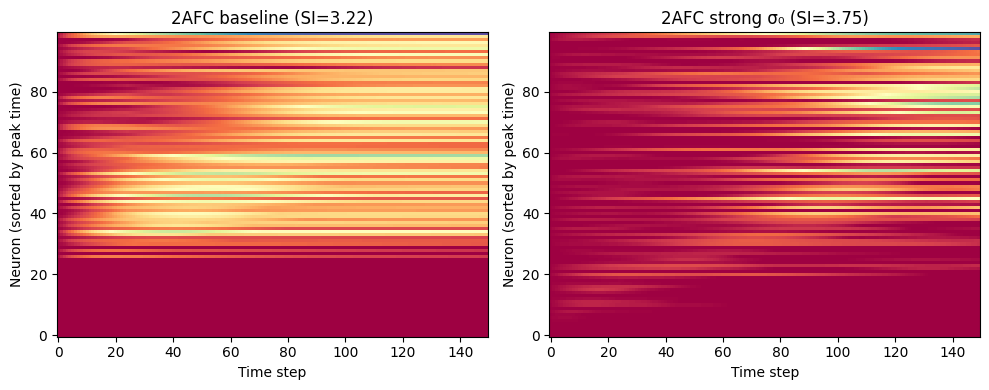

In [115]:
model_2afc_strong, acc_2afc_strong = load_or_train('orhan_2afc_strong_sigma', '2afc',
                                     lambda_0=0.9, sigma_0=0.2, steps=MAX_STEPS)
states_2afc_strong = collect_states(model_2afc_strong, ds_2afc)
si_2afc_strong = compute_sequentiality_index(states_2afc_strong, threshold=0.1, window=5, n_bins=20)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_sorted_heatmap(states_2afc, f'2AFC baseline (SI={si_2afc:.2f})', ax=axes[0])
plot_sorted_heatmap(states_2afc_strong, f'2AFC strong σ₀ (SI={si_2afc_strong:.2f})', ax=axes[1])
plt.tight_layout()
plt.show()

### 5. Experiment 3 — Strong L2 regularization `rho` on COMP

Stronger weight decay penalizes large recurrent weights and pushes the network toward simpler, more persistent representations. We train an additional COMP network with `weight_decay = 1e-3` instead of the baseline `1e-5` and expect lower SI.

Loading orhan_comp_strong_l2 from ./models/15\orhan_comp_strong_l2
[orhan_comp_strong_l2] test accuracy: 0.893


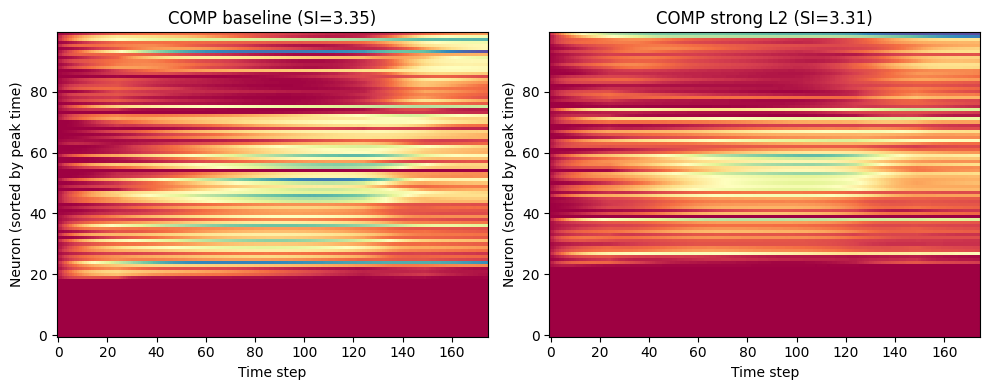

In [116]:
model_comp_strong_l2, acc_comp_strong_l2 = load_or_train('orhan_comp_strong_l2', 'comp',
                                        lambda_0=0.9, sigma_0=0.05, weight_decay=1e-3)
states_comp_strong_l2 = collect_states(model_comp_strong_l2, ds_comp)
si_comp_strong_l2 = compute_sequentiality_index(states_comp_strong_l2, threshold=0.1, window=5, n_bins=20)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_sorted_heatmap(states_comp, f'COMP baseline (SI={si_comp:.2f})', ax=axes[0])
plot_sorted_heatmap(states_comp_strong_l2, f'COMP strong L2 (SI={si_comp_strong_l2:.2f})', ax=axes[1])
plt.tight_layout()
plt.show()

### 6. Experiment 4 — Fixed vs. variable delay

Sequential representations change over time, so they cannot be read out reliably by a fixed decoder at different delay durations. We therefore expect variable-delay 2AFC to show lower SI than fixed-delay 2AFC.

Loading orhan_var2afc from ./models/15\orhan_var2afc
[orhan_var2afc] test accuracy: 1.000


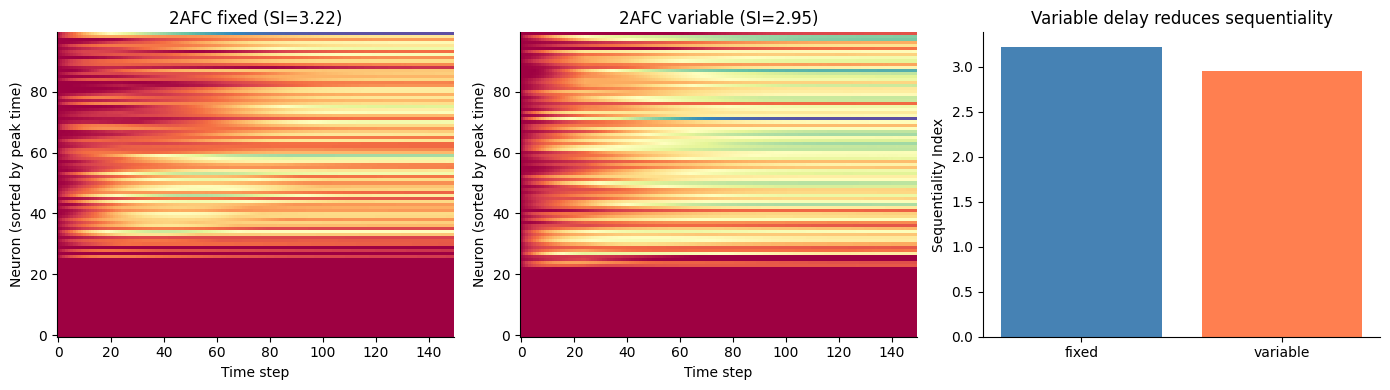

In [117]:
model_var2afc, acc_var2afc = load_or_train('orhan_var2afc', 'var2afc', lambda_0=0.9, sigma_0=0.05)
ds_var2afc = make_dataset('var2afc', num_trials=300, batch_size=300)
states_var2afc = collect_states(model_var2afc, ds_var2afc)
si_var2afc = compute_sequentiality_index(states_var2afc, threshold=0.1, window=5, n_bins=20)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_sorted_heatmap(states_2afc, f'2AFC fixed (SI={si_2afc:.2f})', ax=axes[0])
plot_sorted_heatmap(states_var2afc, f'2AFC variable (SI={si_var2afc:.2f})', ax=axes[1])
axes[2].bar(['fixed', 'variable'], [si_2afc, si_var2afc], color=['steelblue', 'coral'])
axes[2].set_ylabel('Sequentiality Index')
axes[2].set_title('Variable delay reduces sequentiality')
for a in axes:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 7. Non-normal, asymmetric recurrent connectivity

For the COMP network (typically the most sequential), we sort neurons by their peak response time and plot the mean recurrent weight as a function of peak-order lag. High-sequentiality networks show stronger weights from earlier-peaking to later-peaking neurons — a forward-asymmetric, non-normal connectivity pattern.

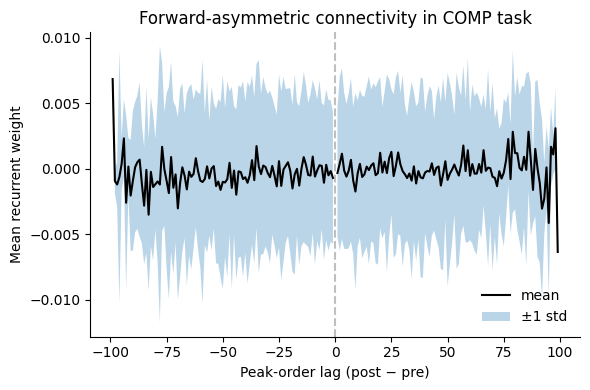

In [119]:
W = model_comp.h2h.weight.detach().cpu().numpy()
_, peak_times = sort_neurons_by_peak_time(states_comp.mean(axis=0))
lags, means, stds = weight_profile_by_peak_order(W, peak_times, max_lag=100)

plt.figure(figsize=(6, 4))
plt.plot(lags, means, 'k-', label='mean')
plt.fill_between(lags, means - stds, means + stds, alpha=0.3, label='±1 std')
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Peak-order lag (post − pre)')
plt.ylabel('Mean recurrent weight')
plt.title('Forward-asymmetric connectivity in COMP task')
plt.legend(frameon=False)
for sp in plt.gca().spines.values():
    if sp.spine_type in ('top', 'right'):
        sp.set_visible(False)
plt.tight_layout()
plt.show()

### 8. Modeling choice: deterministic rate units

Following Orhan & Ma (2019), this notebook uses a deterministic rate RNN with ReLU activation. Single-neuron spiking variability is therefore abstracted away; the units represent trial-averaged firing rates. This is the same modeling choice made in the original paper and is appropriate for asking how task structure and circuit properties shape population-level sequential dynamics.

### 9. Orhan summary

Table of the trained Orhan networks, their Sequentiality Indices, and test accuracies. After running with full training, the expected qualitative ordering is:

- `SI_COMP` > `SI_2AFC`
- `SI_2AFC_strong_sigma0` > `SI_2AFC`
- `SI_COMP_strong_L2` < `SI_COMP`
- `SI_var2AFC` < `SI_2AFC`

In [120]:
summary = pd.DataFrame([
    {'model': '2AFC baseline', 'lambda_0': 0.9, 'sigma_0': 0.05, 'weight_decay': 1e-5, 'SI': si_2afc, 'acc': acc_2afc},
    {'model': 'COMP baseline', 'lambda_0': 0.9, 'sigma_0': 0.05, 'weight_decay': 1e-5, 'SI': si_comp, 'acc': acc_comp},
    {'model': '2AFC strong sigma0', 'lambda_0': 0.9, 'sigma_0': 0.15, 'weight_decay': 1e-5, 'SI': si_2afc_strong, 'acc': acc_2afc_strong},
    {'model': 'COMP strong L2', 'lambda_0': 0.9, 'sigma_0': 0.05, 'weight_decay': 1e-3, 'SI': si_comp_strong_l2, 'acc': acc_comp_strong_l2},
    {'model': 'Variable 2AFC', 'lambda_0': 0.9, 'sigma_0': 0.05, 'weight_decay': 1e-5, 'SI': si_var2afc, 'acc': acc_var2afc},
])
print(summary.to_string(index=False))
print(f"\nModels saved to {MODEL_DIR}/")

             model  lambda_0  sigma_0  weight_decay       SI      acc
     2AFC baseline       0.9     0.05       0.00001 3.218671 1.000000
     COMP baseline       0.9     0.05       0.00001 3.353074 0.903333
2AFC strong sigma0       0.9     0.15       0.00001 3.754781 1.000000
    COMP strong L2       0.9     0.05       0.00100 3.310617 0.893333
     Variable 2AFC       0.9     0.05       0.00001 2.953760 1.000000
     Variable COMP       0.9     0.05       0.00001 3.233639 0.903333

Models saved to ./models/15/


---

## Part II — Zhou et al. (2023): ramp-to-sequence transition in T+WM

In this part we train a Dale-constrained EI-RNN on a **timing + working memory (T+WM)** task. The network must simultaneously remember a cue stimulus and predict the elapsed time until a probe. We track how the delay-period dynamics evolve from low-dimensional persistent/ramping activity early in training to high-dimensional, cue-specific neural sequences as the temporal-expectation component is learned (Figure 3).

### 1. T+WM task generator

The T+WM task is a differential delayed non-match-to-sample (dDNMS) task with an additional temporal-expectation output:

- A cue (A or B) is presented for 150 ms.
- After a delay (1 s for cue A, 2.2 s for cue B on standard trials), a probe is presented for 150 ms.
- The network must report whether cue and probe match (motor output = 0) or do not match (motor output = 0.8 from probe onset).
- At the same time, a temporal-expectation output ramps from 0 to 0.8 during the second half of the delay, anticipating the probe.
- During training, the cue–delay association is reversed on 10% of trials, and both the first-stimulus onset time and the delay duration are jittered. The test set uses fixed standard timings and no reversal trials.

The fixation channel (index 0) is held at 0, matching the reference implementation. Cues are encoded as non-overlapping Gaussian bumps on a 32-unit ring.


In [2]:
def _gaussian_bump(center, n=N_STIM, sigma=CUE_SIGMA):
    xs = np.arange(n)
    return np.exp(-0.5 * ((xs - center) / sigma) ** 2)


def generate_zhou_twm(num_trials=1000, mode='train', seed=None):
    """Generate Zhou 2023 T+WM trials.

    Returns
    -------
    inputs, targets, mask, conditions
        Shapes: (N, T, 33), (N, T, 2), (N, T, 2), list[dict].
    """
    rng = np.random.RandomState(seed)

    cues = rng.randint(0, 2, size=num_trials)        # 0 = A, 1 = B
    matches = rng.randint(0, 2, size=num_trials)     # 1 = match, 0 = non-match
    invalid = (rng.rand(num_trials) < 0.1) if mode == 'train' else np.zeros(num_trials, dtype=bool)

    # Standard delay is predicted by cue; invalid trials reverse it.
    delay_short = np.where(invalid, 1 - cues, cues).astype(bool)
    delay_steps = np.where(delay_short, SHORT_DELAY, LONG_DELAY)
    if mode == 'train':
        jitter = rng.uniform(0.9, 1.1, size=num_trials)
        delay_steps = (delay_steps * jitter).astype(int)

    stim2 = np.where(matches, cues, 1 - cues)

    if mode == 'train':
        stim1_on = (rng.uniform(250, 1000, size=num_trials) / DT).astype(int)
    else:
        stim1_on = np.full(num_trials, int(1000 / DT), dtype=int)

    stim1_off = stim1_on + STIM_DUR
    stim2_on = stim1_off + delay_steps
    stim2_off = stim2_on + STIM_DUR
    tdim = int(stim2_off.max() + POST_MASK)

    inputs = np.zeros((num_trials, tdim, N_INPUT), dtype=np.float32)
    targets = np.zeros((num_trials, tdim, OUTPUT_DIM), dtype=np.float32)
    mask = np.zeros((num_trials, tdim, OUTPUT_DIM), dtype=np.float32)
    conditions = []

    cue_bumps = [_gaussian_bump(c) for c in CUE_CENTERS]

    for i in range(num_trials):
        # ring inputs
        inputs[i, stim1_on[i]:stim1_off[i], 1:] += cue_bumps[cues[i]]
        inputs[i, stim2_on[i]:stim2_off[i], 1:] += cue_bumps[stim2[i]]

        # motor target: 0.8 on non-match trials from probe onset
        if matches[i] == 0:
            targets[i, stim2_on[i]:, 0] = 0.8

        # temporal-expectation target: half ramp from mid-delay to probe, then 0.8
        mid_delay = stim1_off[i] + delay_steps[i] // 2
        ramp_len = stim2_on[i] - mid_delay
        if ramp_len > 0:
            targets[i, mid_delay:stim2_on[i], 1] = np.linspace(0.0, 0.8, ramp_len, endpoint=False)
        targets[i, stim2_on[i]:, 1] = 0.8

        # masks
        pre_start = max(0, stim1_on[i] - PRE_MASK)
        mask[i, pre_start:stim2_on[i], 0] = 2.0
        mask[i, stim2_on[i] + GRACE:min(stim2_off[i] + POST_MASK, tdim), 0] = 5.0
        mask[i, pre_start:min(stim2_off[i] + POST_MASK, tdim), 1] = 1.0

        conditions.append({
            'cue': int(cues[i]),
            'match': bool(matches[i]),
            'invalid': bool(invalid[i]),
            'delay_steps': int(delay_steps[i]),
            'stim1_on': int(stim1_on[i]),
            'stim1_off': int(stim1_off[i]),
            'stim2_on': int(stim2_on[i]),
            'stim2_off': int(stim2_off[i]),
        })

    return (torch.from_numpy(inputs),
            torch.from_numpy(targets),
            torch.from_numpy(mask),
            conditions)


def make_dataset(num_trials, mode='train', seed=None, batch_size=BATCH_SIZE):
    inputs, targets, mask, conds = generate_zhou_twm(num_trials=num_trials, mode=mode, seed=seed)
    return CognitiveTaskDataset(inputs, targets, mask, conds,
                                task_name=f'zhou_twm_{mode}', batch_size=batch_size)


# Build test set once; we will reuse it for all analyses.
ds_test = make_dataset(NUM_TEST_TRIALS, mode='test', seed=SEED + 1, batch_size=NUM_TEST_TRIALS)
print('test set:', ds_test.inputs.shape, ds_test.targets.shape, ds_test.mask.shape)


test set: torch.Size([256, 400, 33]) torch.Size([256, 400, 2]) torch.Size([256, 400, 2])


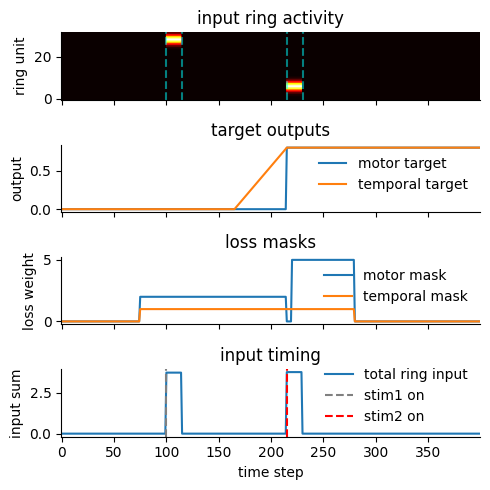

In [22]:
# Visualize one example trial (cue A, long delay, non-match)
fig, axes = plt.subplots(4, 1, figsize=(5, 5), sharex=True)

idx = 0
while ds_test.conditions[idx]['cue'] != 1 or ds_test.conditions[idx]['match']:
    idx += 1
cond = ds_test.conditions[idx]

axes[0].imshow(ds_test.inputs[idx, :, 1:].T, aspect='auto', origin='lower', cmap='hot')
axes[0].set_ylabel('ring unit')
axes[0].set_title('input ring activity')
for t in [cond['stim1_on'], cond['stim1_off'], cond['stim2_on'], cond['stim2_off']]:
    axes[0].axvline(t, color='cyan', linestyle='--', alpha=0.5)

axes[1].plot(ds_test.targets[idx, :, 0], label='motor target')
axes[1].plot(ds_test.targets[idx, :, 1], label='temporal target')
axes[1].set_ylabel('output')
axes[1].set_title('target outputs')
axes[1].legend(frameon=False)

axes[2].plot(ds_test.mask[idx, :, 0], label='motor mask')
axes[2].plot(ds_test.mask[idx, :, 1], label='temporal mask')
axes[2].set_ylabel('loss weight')
axes[2].set_title('loss masks')
axes[2].legend(frameon=False)

axes[3].plot(ds_test.inputs[idx, :, 1:].sum(axis=1), label='total ring input')
axes[3].axvline(cond['stim1_on'], color='gray', linestyle='--', label='stim1 on')
axes[3].axvline(cond['stim2_on'], color='red', linestyle='--', label='stim2 on')
axes[3].set_xlabel('time step')
axes[3].set_ylabel('input sum')
axes[3].set_title('input timing')
axes[3].legend(frameon=False)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### 2. Dale-constrained EI-RNN model

We use NeuralRNN's `ei_rnn` model, which is a CTRNN with Dale's-law enforcement:

- 256 recurrent units, 80% excitatory (first 205 units) and 20% inhibitory (last 51 units).
- Leaky ReLU dynamics with `α = dt / τ = 0.2`.
- Recurrent noise during training (`σ_rec = 0.005`).
- Readout from all units (the paper does not restrict readout to excitatory cells).

To match the paper's training constraints, we **freeze the input weights and the recurrent bias**, and train only `W_rec`, `W_out`, and the output bias. We also clip recurrent weights to stay non-negative after each optimizer step; the Dale sign mask then turns them into signed E/I weights during the forward pass.


In [ ]:
def init_zhou_recurrent(model, seed=SEED):
    """Initialize recurrent weights like Zhou et al.: random orthogonal gain 0.5,
    inhibitory presynaptic rows scaled by E/I ratio, no autapses, positive magnitudes."""
    rng = np.random.RandomState(seed)
    M = model.config.latent_dim
    e_size = int(round(M * model.config.ei_ratio))
    i_size = M - e_size

    A = rng.randn(M, M)
    Q, _ = np.linalg.qr(A)
    W = 0.5 * Q
    W[e_size:, :] *= (e_size / i_size)   # scale inhibitory presynaptic rows
    np.fill_diagonal(W, 0.0)             # remove autapses
    W = np.abs(W)

    with torch.no_grad():
        model.h2h.weight.copy_(torch.from_numpy(W).float())
        torch.nn.init.normal_(model.input2h.weight, 0.0, 1.0 / np.sqrt(model.config.input_dim))
        if model.input2h.bias is not None:
            model.input2h.bias.zero_()
        if model.h2h.bias is not None:
            model.h2h.bias.zero_()
        torch.nn.init.normal_(model.readout_layer.weight, 0.0, 0.01)
        if model.readout_layer.bias is not None:
            model.readout_layer.bias.zero_()


def clip_recurrent_weights(model):
    """Post-step hook: keep recurrent magnitudes non-negative."""
    with torch.no_grad():
        model.h2h.weight.data.clamp_(min=0.0)


def build_model(latent_dim=LATENT_DIM):
    cfg = AutoConfig.for_model(
        'ei_rnn',
        input_dim=N_INPUT,
        latent_dim=latent_dim,
        output_dim=OUTPUT_DIM,
        dt=DT,
        tau=50.0,
        activation='relu',
        dale=True,
        ei_ratio=0.8,
        sigma_rec=0.05,
        readout_e_only=False,
        trainable_h0=False,
    )
    model = AutoModel.from_config(cfg)
    init_zhou_recurrent(model, seed=SEED)

    # Freeze input weights/bias and recurrent bias; train h2h.weight and readout.
    model.freeze_parameters(groups=['input'], patterns=[r'^input2h\.bias$'])
    model.freeze_parameters(patterns=[r'^h2h\.bias$'])
    return model


# quick sanity check
model = build_model()
print('trainable params:')
for n, p in model.named_parameters():
    if p.requires_grad:
        print(f'  {n}: {tuple(p.shape)}')


trainable params:
  h2h.weight: (128, 128)
  readout_layer.weight: (2, 128)
  readout_layer.bias: (2,)


### 3. Load or train the T+WM network

If a final checkpoint already exists in `./models/15/zhou_twm/`, we load it. Otherwise we train from scratch, saving intermediate checkpoints every `SAVE_EVERY` steps. This makes the notebook re-runnable without repeating the full training run.

In [ ]:
def train_zou_twm():
    """Train the T+WM network and save the final model + checkpoints."""
    ds_train = make_dataset(NUM_TRAIN_TRIALS, mode='train', seed=SEED, batch_size=BATCH_SIZE)
    model = build_model(latent_dim=LATENT_DIM)

    objective = RegularizedSupervisedObjective(
        task_type='regression',
        activity_weight=1e-6,
        mse_reduce='global',
    )

    args = TrainingArguments(
        max_steps=MAX_STEPS,
        batch_size=BATCH_SIZE,
        learning_rate=LR,
        grad_clip_norm=1.0,
        log_every=200,
        save_every=SAVE_EVERY,
        early_stop_loss=0.000001,
        output_dir=output_dir,
        device=device,
        seed=SEED,
    )

    trainer = Trainer(model, ds_train, objective, args,
                      post_step_hook=clip_recurrent_weights)
    trainer.train()

    os.makedirs(output_dir, exist_ok=True)
    model.save_pretrained(output_dir)
    print('Final model saved to', output_dir)
    return output_dir

output_dir = os.path.join(MODEL_DIR, f'zhou_twm')
if os.path.exists(os.path.join(output_dir, 'config.json')):
    print('Loading existing final model from', output_dir)
    model = AutoModel.from_pretrained(output_dir)
else:
    print('No checkpoint found; training a new model.')
    output_dir = train_zou_twm()
    model = AutoModel.from_pretrained(output_dir)

model.to(device)
model.eval()
print('Model ready:', model.config.model_type, '| latent_dim:', model.config.latent_dim)


No checkpoint found; training a new model.
[train] step=0  loss=0.1460  task_loss=0.1460  activity_loss=0.0264
[train] step=200  loss=0.0660  task_loss=0.0660  activity_loss=0.3336
[train] step=400  loss=0.0673  task_loss=0.0673  activity_loss=0.2272
[train] step=600  loss=0.0246  task_loss=0.0246  activity_loss=0.5655
[train] step=800  loss=0.0226  task_loss=0.0226  activity_loss=0.3918
[train] step=1000  loss=0.0177  task_loss=0.0177  activity_loss=0.4489
[train] step=1200  loss=0.0207  task_loss=0.0207  activity_loss=0.7011
[train] step=1400  loss=0.0061  task_loss=0.0061  activity_loss=0.5216
[train] step=1600  loss=0.0052  task_loss=0.0052  activity_loss=0.4287
[train] step=1800  loss=0.0056  task_loss=0.0056  activity_loss=0.3552
[train] step=2000  loss=0.0027  task_loss=0.0027  activity_loss=0.2877
[train] step=2200  loss=0.0024  task_loss=0.0024  activity_loss=0.3049
[train] step=2400  loss=0.0050  task_loss=0.0050  activity_loss=0.3136
[train] step=2600  loss=0.0045  task_loss

### 4. Evaluation helpers

We need a few helper functions to quantify behavior and dynamics:

- **Motor accuracy**: fraction of test trials where the averaged response-period motor output is on the correct side of the decision threshold.
- **Timing MSE**: masked mean-squared error of the temporal-expectation output during the delay.
- **Effective dimensionality**: number of PCs needed to explain 95% of the variance of the concatenated mean short/long delay activity.
- **Sequentiality index**: Orhan & Ma's SI computed over the delay-period hidden states.
- **Time-decoding correlation**: linear-SVM decoding of elapsed time from 100 ms binned population activity, averaged across the two cues.


In [31]:
def collect_states(model, dataset, device=device):
    """Return hidden states (N, T, M) for all trials in the dataset."""
    model.eval()
    with torch.no_grad():
        batch = dataset.get_all_trials()
        inputs = batch['inputs'].to(device)
        out = model(inputs)
    return out.states.cpu().numpy()


def motor_accuracy(outputs, conditions, threshold=0.4):
    """Motor accuracy from response-period averaged outputs."""
    outputs = outputs.cpu().numpy() if torch.is_tensor(outputs) else outputs
    preds = []
    true = []
    for i, cond in enumerate(conditions):
        resp_start = cond['stim2_on'] + GRACE
        resp_end = cond['stim2_off'] + POST_MASK
        mean_resp = outputs[i, resp_start:resp_end, 0].mean()
        pred_nonmatch = mean_resp > threshold
        preds.append(pred_nonmatch)
        true.append(not cond['match'])
    preds = np.array(preds)
    true = np.array(true)
    return (preds == true).mean()


def timing_mse(outputs, targets, mask):
    """Masked MSE of the temporal-expectation output."""
    if torch.is_tensor(outputs):
        outputs = outputs.cpu()
        targets = targets.cpu()
        mask = mask.cpu()
    m = mask[:, :, 1].float()
    err = (outputs[:, :, 1] - targets[:, :, 1]) ** 2
    return (err * m).sum().item() / m.sum().item()


def delay_dimensionality(states, conditions):
    """Effective dimensionality of concatenated mean short/long delay activity."""
    short = []
    long = []
    for i, cond in enumerate(conditions):
        delay = states[i, cond['stim1_off']:cond['stim2_on']]
        if cond['delay_steps'] == SHORT_DELAY:
            short.append(delay)
        elif cond['delay_steps'] == LONG_DELAY:
            long.append(delay)
    short = np.stack(short).mean(axis=0)   # (T_short, M)
    long = np.stack(long).mean(axis=0)     # (T_long, M)
    concat = np.concatenate([short, long], axis=0)  # (T_short+T_long, M)
    return effective_dimensionality(concat, variance_threshold=0.95)


def sequentiality_over_delay(states, conditions):
    """Sequentiality index over long-delay-period states."""
    delay_states = []
    for i, cond in enumerate(conditions):
        if cond['delay_steps'] == LONG_DELAY:
            delay_states.append(states[i, cond['stim1_off']:cond['stim2_on']])
    delay_states = np.stack(delay_states)  # (N, T_long, M)
    return compute_sequentiality_index(delay_states, threshold=0.1, window=5, n_bins=20)


def decode_time_correlation(states, conditions, bin_len=10, seed=SEED):
    """Decode elapsed time within each cue using a linear SVM; return mean correlation."""

    def _decode(states_list):
        X, y = [], []
        for s in states_list:
            n_bins = s.shape[0] // bin_len
            feats = []
            for b in range(n_bins):
                feats.append(s[b * bin_len:(b + 1) * bin_len].mean(axis=0))
            X.append(np.stack(feats))   # (n_bins, M)
            y.append(np.arange(n_bins))
        X = np.concatenate(X, axis=0)   # (total_samples, M)
        y = np.concatenate(y)           # (total_samples,)
        if len(np.unique(y)) < 2:
            return np.nan
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
        clf = LinearSVC(C=1.0, max_iter=5000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        return np.corrcoef(y_pred, y_test)[0, 1]

    corrs = []
    for cue in [0, 1]:
        cue_states = [states[i, cond['stim1_off']:cond['stim2_on']]
                      for i, cond in enumerate(conditions)
                      if cond['cue'] == cue]
        corrs.append(_decode(cue_states))
    return float(np.nanmean(corrs))


# Run a full evaluation on the final model 
states_test = collect_states(model, ds_test)
with torch.no_grad():
    out_test = model(ds_test.inputs.to(device))

print('Motor accuracy :', motor_accuracy(out_test.outputs, ds_test.conditions))
print('Timing MSE     :', timing_mse(out_test.outputs, ds_test.targets, ds_test.mask))
print('Dimensionality :', delay_dimensionality(states_test, ds_test.conditions))
print('Sequentiality  :', sequentiality_over_delay(states_test, ds_test.conditions))
print('Time decode r  :', decode_time_correlation(states_test, ds_test.conditions))


Motor accuracy : 1.0
Timing MSE     : 0.03080275185389001
Dimensionality : 4
Sequentiality  : 2.699833934853874
Time decode r  : 0.9997330896025698


### 5. Figure 3: ramp-to-sequence transition across training

We load all saved checkpoints (or just the final model if checkpoints are not present) and evaluate the same set of metrics on the fixed test set. This reveals how the network first solves the WM component and then develops high-dimensional, sequence-like dynamics as the timing component is learned.


In [35]:
def find_checkpoints(model_dir=MODEL_DIR):
    """Return sorted list of (step, path) checkpoint directories."""
    cp_dir = os.path.join(model_dir, f'zhou_twm')
    if not os.path.isdir(cp_dir):
        return []
    checkpoints = []
    for p in glob.glob(os.path.join(cp_dir, 'checkpoint-*')):
        try:
            step = int(os.path.basename(p).split('-')[-1])
            checkpoints.append((step, p))
        except ValueError:
            continue
    checkpoints.sort()
    return checkpoints


def evaluate_checkpoint(path, dataset=ds_test):
    """Load a checkpoint and compute all dynamics metrics."""
    m = AutoModel.from_pretrained(path)
    m.to(device)
    states = collect_states(m, dataset)
    with torch.no_grad():
        outs = m(dataset.inputs.to(device))
    return {
        'motor_acc': motor_accuracy(outs.outputs, dataset.conditions),
        'timing_mse': timing_mse(outs.outputs, dataset.targets, dataset.mask),
        'dimensionality': delay_dimensionality(states, dataset.conditions),
        'sequentiality': sequentiality_over_delay(states, dataset.conditions),
        'time_decode_r': decode_time_correlation(states, dataset.conditions),
    }


checkpoints = find_checkpoints()
if checkpoints:
    records = []
    for step, path in checkpoints:
        metrics = evaluate_checkpoint(path)
        records.append({'step': step, **metrics})
        print(f'step {step:5d}: {metrics}')
    final_metrics = evaluate_checkpoint(output_dir)
    records.append({'step': MAX_STEPS, **final_metrics})
    df = pd.DataFrame(records)
else:
    print('No checkpoints found; evaluating final model only.')
    final_metrics = evaluate_checkpoint(output_dir)
    df = pd.DataFrame([{'step': MAX_STEPS, **final_metrics}])

df


step  1000: {'motor_acc': 1.0, 'timing_mse': 0.035856712993243, 'dimensionality': 3, 'sequentiality': 1.6817634767859082, 'time_decode_r': 0.9975068081578421}
step  2000: {'motor_acc': 1.0, 'timing_mse': 0.016256749106885102, 'dimensionality': 3, 'sequentiality': 2.4441003325750077, 'time_decode_r': 0.9987676269157446}
step  3000: {'motor_acc': 1.0, 'timing_mse': 0.022069711663155852, 'dimensionality': 3, 'sequentiality': 2.5830580293234577, 'time_decode_r': 0.9990205155006625}
step  4000: {'motor_acc': 1.0, 'timing_mse': 0.02600752409831481, 'dimensionality': 4, 'sequentiality': 2.5823598990025474, 'time_decode_r': 0.9997330896025698}


,step,motor_acc,timing_mse,dimensionality,sequentiality,time_decode_r
0,1000,1.0,0.035857,3,1.681763,0.997507
1,2000,1.0,0.016257,3,2.444100,0.998768
2,3000,1.0,0.022070,3,2.583058,0.999021
3,4000,1.0,0.026008,4,2.582360,0.999733
4,10000,1.0,0.030803,4,2.699834,0.999733


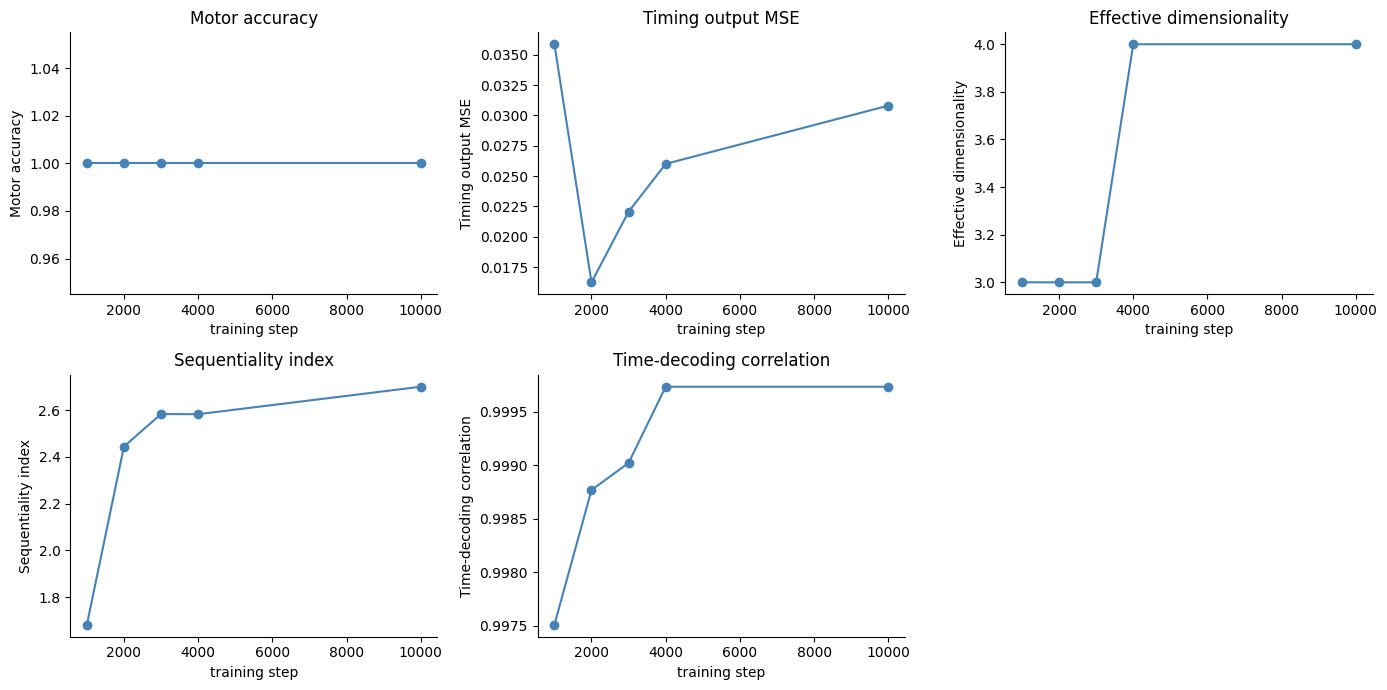

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

metrics = [
    ('motor_acc', 'Motor accuracy'),
    ('timing_mse', 'Timing output MSE'),
    ('dimensionality', 'Effective dimensionality'),
    ('sequentiality', 'Sequentiality index'),
    ('time_decode_r', 'Time-decoding correlation'),
]

for ax, (col, title) in zip(axes, metrics):
    ax.plot(df['step'], df[col], 'o-', color='steelblue')
    ax.set_xlabel('training step')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].axis('off')
plt.tight_layout()
plt.show()


#### Sorted neurograms at available checkpoints

For the saved checkpoints we sort the active units by their peak firing time during the long delay and visualize the average delay-period activity. In a full sequence regime these panels show transient peaks marching across time; in the current run the dynamics are closer to persistent/ramping activity.

(220, 128)
(220, 128)
(220, 128)
(220, 128)


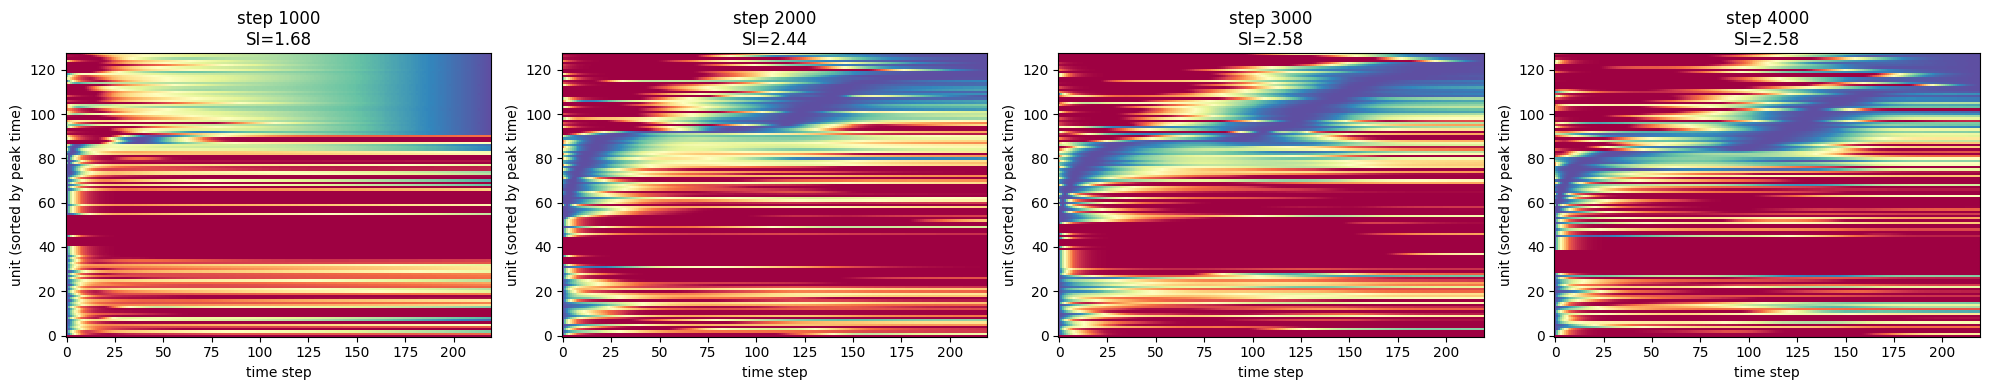

In [46]:
def plot_sorted_neurogram(states, conditions, title, ax=None, n_show=None):
    """Plot units sorted by peak time during the long delay."""
    # average over long-delay trials
    long_states = []
    for i, cond in enumerate(conditions):
        if cond['delay_steps'] == LONG_DELAY:
            long_states.append(states[i, cond['stim1_off']:cond['stim2_on']])
    long_mean = np.stack(long_states).mean(axis=0)  # (T, M)
    
    mean_act = long_mean.mean(axis=0)
    if n_show is None:
        n_show = long_mean.shape[1]
    top_idx = np.argsort(mean_act)[-n_show:]
    sub = long_mean[:, top_idx]
    print(sub.shape)
    _, sort_idx = sort_neurons_by_peak_time(sub)
    sorted_act = sub[:, sort_idx].T

    # normalize each unit to [0, 1]
    sorted_act = sorted_act / (sorted_act.max(axis=1, keepdims=True) + 1e-8)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(sorted_act, aspect='auto', cmap='Spectral', origin='lower', interpolation='none')
    ax.set_title(title)
    ax.set_xlabel('time step')
    ax.set_ylabel('unit (sorted by peak time)')
    return ax


if len(checkpoints) >= 4:
    idxs = [0, 1, 2, 3]
    selected = [(checkpoints[i][0], checkpoints[i][1]) for i in idxs]
else:
    selected = [(MAX_STEPS, output_dir)]

fig, axes = plt.subplots(1, len(selected), figsize=(5 * len(selected), 4))
if len(selected) == 1:
    axes = [axes]
for ax, (step, path) in zip(axes, selected):
    m = AutoModel.from_pretrained(path)
    m.to(device)
    states = collect_states(m, ds_test)
    si = sequentiality_over_delay(states, ds_test.conditions)
    plot_sorted_neurogram(states, ds_test.conditions,
                          f'step {step}\nSI={si:.2f}', ax=ax, n_show=LATENT_DIM)
plt.tight_layout()
plt.show()


In [ ]:
summary = pd.DataFrame([{
    'latent_dim': model.config.latent_dim,
    'motor_accuracy': final_metrics['motor_acc'],
    'timing_mse': final_metrics['timing_mse'],
    'dimensionality': final_metrics['dimensionality'],
    'sequentiality': final_metrics['sequentiality'],
    'time_decode_r': final_metrics['time_decode_r'],
}])
print(summary.to_string(index=False))
print('Model directory:', MODEL_DIR)

### 9. Zhou summary

Final T+WM metrics after training. With the default settings the network converges to near-perfect motor accuracy and low timing MSE. The ramp-to-sequence transition is captured by tracking effective dimensionality, sequentiality, and elapsed-time decodability across saved checkpoints.

### References

- Orhan, A. E. & Ma, W. J. (2019). A diverse range of factors affect the nature of neural representations underlying short-term memory. *Nature Neuroscience*, 22, 275–283.
- Zhou, S., Seay, M., Taxidis, J., Golshani, P. & Buonomano, D. V. (2023). Multiplexing working memory and time in the trajectories of neural networks. *Nature Human Behaviour*, 7, 1056–1070.